In [69]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [70]:

col_names = [
    'unit_number', 'time_in_cycles', 'alt_setting_1', 'mach_setting_2', 'tra_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 
    'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 
    'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 
    'sensor_20', 'sensor_21'
]

train_df = pd.read_csv('train_FD001.txt', sep= r'\s+', header=None, names=col_names)

max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.rename(columns={'time_in_cycles' : 'max_cycle'}, inplace =True)

train_df = train_df.merge(max_cycles, on='unit_number', how='left')
train_df["RUL"] = train_df['max_cycle']-train_df['time_in_cycles']
train_df.drop(columns=['max_cycle'],inplace = True)
train_df


,unit_number,time_in_cycles,alt_setting_1,mach_setting_2,tra_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


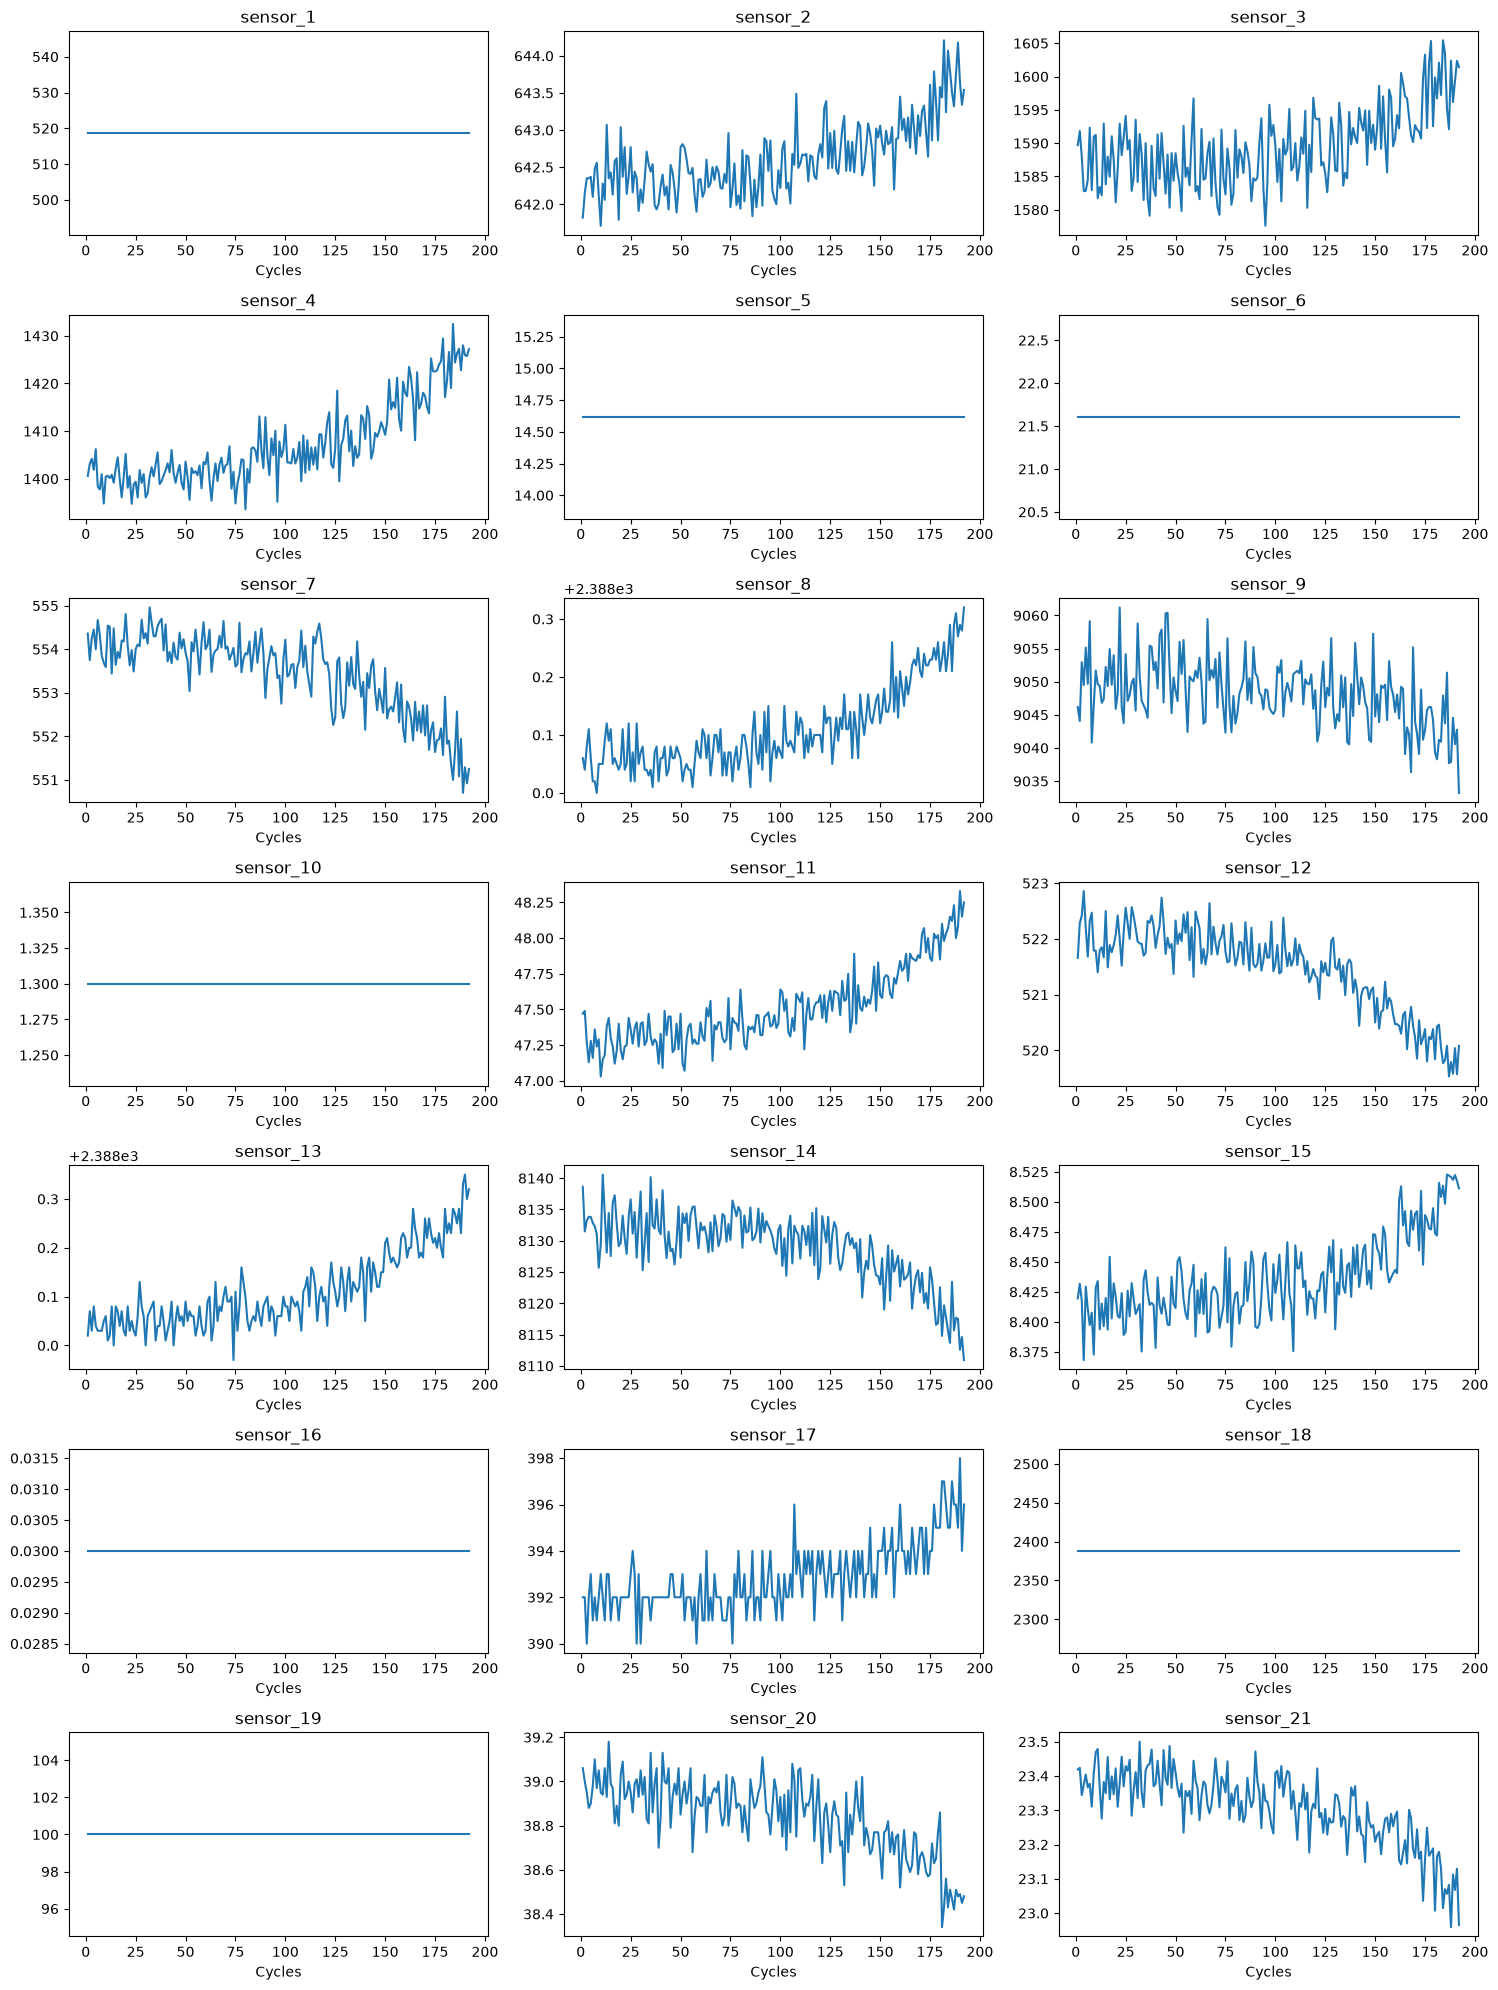

In [71]:
engine_1_data = train_df[train_df['unit_number'] == 1]

ffig, axes = plt.subplots(7, 3, figsize=(15, 20))
axes = axes.ravel() 

for i in range(1,22):
    sensor_col = f'sensor_{i}'
    axes[i-1].plot(engine_1_data['time_in_cycles'],engine_1_data[sensor_col])
    axes[i-1].set_title(sensor_col)
    axes[i-1].set_xlabel("Cycles")

plt.tight_layout()
plt.show()

In [72]:
cols_2_drop = ['sensor_1','sensor_5','sensor_6','sensor_10','sensor_16','sensor_18','sensor_19',
                'alt_setting_1', 'mach_setting_2', 'tra_setting_3']

train_df.drop(columns=cols_2_drop,inplace=True)
train_df.head()


,unit_number,time_in_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [73]:
from sklearn.preprocessing import MinMaxScaler

cols_2_scale =train_df.columns.difference(['unit_number', 'time_in_cycles', 'RUL'])

scaler =MinMaxScaler()

train_df[cols_2_scale]= scaler.fit_transform(train_df[cols_2_scale])
train_df.head()

,unit_number,time_in_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191
1,1,2,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190
2,1,3,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189
3,1,4,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188
4,1,5,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187


In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [75]:
x_train = train_df[cols_2_scale]
y_train = train_df["RUL"]

lin_model = LinearRegression()
lin_model.fit(x_train,y_train)

pred = lin_model.predict(x_train)

mae = mean_absolute_error(y_train,pred)
rmse = np.sqrt(mean_squared_error(y_train,pred))

print(mae)
print(rmse)


34.115286564981574
44.66819159545428


In [79]:
#testing
test_df = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None, names=col_names)
y_test = pd.read_csv('RUL_FD001.txt', sep=r'\s+', header=None, names=['True_RUL'])

test_last_cycle = test_df.groupby('unit_number').last().reset_index()
test_last_cycle.drop(columns=cols_2_drop,inplace=True)

x_test= test_last_cycle[cols_2_scale]
x_test=scaler.transform(x_test)

test_pred = lin_model.predict(x_test)

actual_mae = mean_absolute_error(y_test,test_pred)
actual_rmse = np.sqrt(mean_squared_error(y_test,test_pred))

print(actual_mae)
print(actual_rmse)

25.540326671238407
31.952633027739388


D:\Program Files\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
